# 06 — Multivariate Feature Analysis

Features in relation to **each other**, not the target. Where notebook 05 asked "does this feature predict?", this asks "how much of this feature set is redundant?" — 41 features may really be a dozen independent signals wearing different names.

Sections:
1. **Correlation heatmap** — the full feature×feature matrix
2. **Redundant pairs** — feature pairs that are near-duplicates
3. **PCA** — effective dimensionality (how many components explain the variance)
4. **VIF** — multicollinearity per feature (matters for the linear baseline)
5. **Correlation clustering** — a dendrogram grouping redundant families
6. **Per-sector profiles** — how average feature values differ across sectors

None of this is fatal for a tree model, which tolerates redundancy — but it tells you which features to prune, why the linear baseline may be unstable, and how much independent information the set actually holds.

In [20]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
sns.set_theme(style="white", palette="colorblind")

In [21]:
# Ensure the project root is on the import path so `src` can be imported.
PROJECT_ROOT = Path.cwd().resolve()
for parent in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (parent / 'src').is_dir():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError('Run this notebook from inside the StockForecastRisk repository.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.forecast_engine.features.schema import FEATURE_NAMES, MACRO_FEATURE_NAMES_FULL_HISTORY
from src.forecast_engine.data.loader import PROCESSED_FEATURES_PATH, load_processed_features

data = load_processed_features()
data["date"] = pd.to_datetime(data["date"])

print(f'Loaded {len(data):,} rows for {data["symbol"].nunique():,} tickers')
print(f'Source: {PROCESSED_FEATURES_PATH}')
data.head()

Loaded 622,731 rows for 502 tickers
Source: D:\StockForecastRisk\data\processed\sp500_features.parquet


,date,symbol,security,gics_sector,gics_sub_industry,adj_close,close,high,low,open,...,treasury_2y,fed_funds_rate,vix_term_ratio,yield_curve_slope,vix_change_5d,hy_credit_spread_change_5d,yield_curve_slope_change_5d,vix_change_20d,hy_credit_spread_change_20d,yield_curve_slope_change_20d
0,2021-07-19,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,142.434052,147.580002,147.970001,146.949997,147.660004,...,0.21,0.1,0.903614,0.98,6.17,NaN,-0.16,6.48,NaN,-0.24
1,2021-07-20,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,144.094101,149.300003,151.250000,147.830002,148.449997,...,0.20,0.1,0.850431,1.03,2.72,NaN,-0.05,3.90,NaN,-0.17
2,2021-07-21,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,143.756302,148.949997,149.910004,147.600006,149.490005,...,0.22,0.1,0.818930,1.08,-0.54,NaN,0.02,2.43,NaN,-0.15
3,2021-07-22,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,145.059174,150.300003,150.500000,148.669998,149.710007,...,0.20,0.1,0.809241,1.07,-0.76,NaN,0.01,2.62,NaN,-0.13
4,2021-07-23,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,146.999084,152.309998,152.410004,150.429993,150.589996,...,0.22,0.1,0.794457,1.08,-1.25,NaN,0.02,2.13,NaN,-0.12


In [22]:
# Complete-case feature matrix. Zero-variance (constant) features are dropped up
# front: a constant column has undefined correlation, which would fill the whole
# matrix with NaN and break PCA, VIF, and the dendrogram. Reporting them is itself
# useful -- a feature that never varies carries no information.
# Macro factors (full-history subset; late-start credit spreads excluded) join
# the redundancy analysis if present. Being market-wide, they are prime
# candidates for redundancy with the per-ticker rolling-volatility features --
# which is exactly what VIF and the correlation heatmap below will reveal.
macro_present = [c for c in MACRO_FEATURE_NAMES_FULL_HISTORY if c in data.columns and data[c].notna().any()]
candidate = [c for c in FEATURE_NAMES if c in data.columns and data[c].notna().any()] + macro_present
clean = data.dropna(subset=candidate)

variances = clean[candidate].var()
zero_variance = variances[variances == 0].index.tolist()
features = [c for c in candidate if c not in zero_variance]

if zero_variance:
    print(f"Dropped zero-variance features (no information): {zero_variance}")
print(f"features analysed : {len(features)}")
print(f"complete-case rows: {len(clean):,}")

features analysed : 53
complete-case rows: 520,553


### Note on short interest (2018+ coverage)

The short-interest features (`short_interest`, `short_interest_change`, `days_to_cover`,
`days_to_cover_change`) are the first non-price features. FINRA API coverage begins
~2018, so they are ~48% NaN over the full 2010–2026 panel. Their statistics in this
notebook therefore reflect the **2018+ subset only** — the `notna()` filtering above
already restricts each feature's computation to its available rows, so the numbers are
valid, but read short-interest rows as "2018 onward" rather than full-history. This is
the same partial-coverage caveat as the late-start credit spreads (see schema and
notebook 01). Any conclusion that hinges on short interest specifically should be
confirmed on an explicitly 2018-scoped slice.

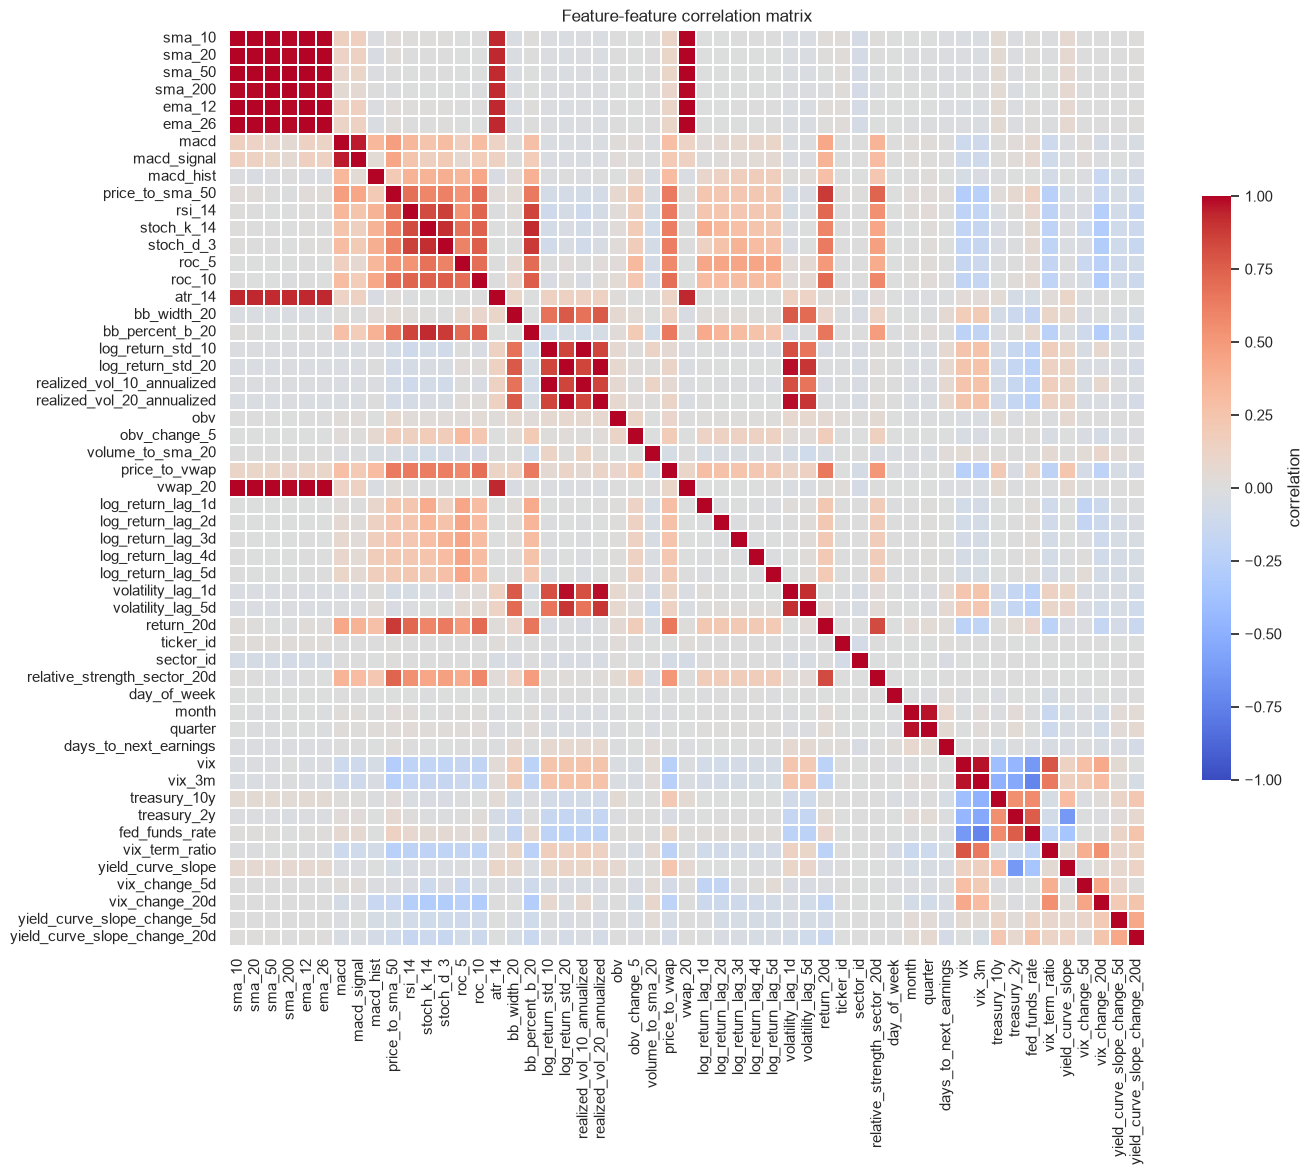

In [23]:
corr = clean[features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.6, "label": "correlation"},
    ax=ax,
)
ax.set_title("Feature-feature correlation matrix")
plt.tight_layout()
plt.show()

In [24]:
REDUNDANCY_THRESHOLD = 0.9

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
redundant = (
    upper.stack()
    .rename("corr")
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
)
redundant = redundant[redundant["corr"].abs() > REDUNDANCY_THRESHOLD]
redundant = redundant.reindex(redundant["corr"].abs().sort_values(ascending=False).index)

print(f"{len(redundant)} feature pairs with |corr| > {REDUNDANCY_THRESHOLD}:")
display(redundant.round(3).reset_index(drop=True))

38 feature pairs with |corr| > 0.9:


,feature_a,feature_b,corr
0,log_return_std_20,realized_vol_20_annualized,1.000
1,log_return_std_10,realized_vol_10_annualized,1.000
2,sma_10,ema_12,1.000
3,sma_20,ema_26,1.000
4,sma_20,ema_12,1.000
5,sma_20,vwap_20,1.000
6,ema_12,ema_26,1.000
7,ema_26,vwap_20,1.000
8,sma_10,sma_20,1.000
9,sma_10,ema_26,1.000


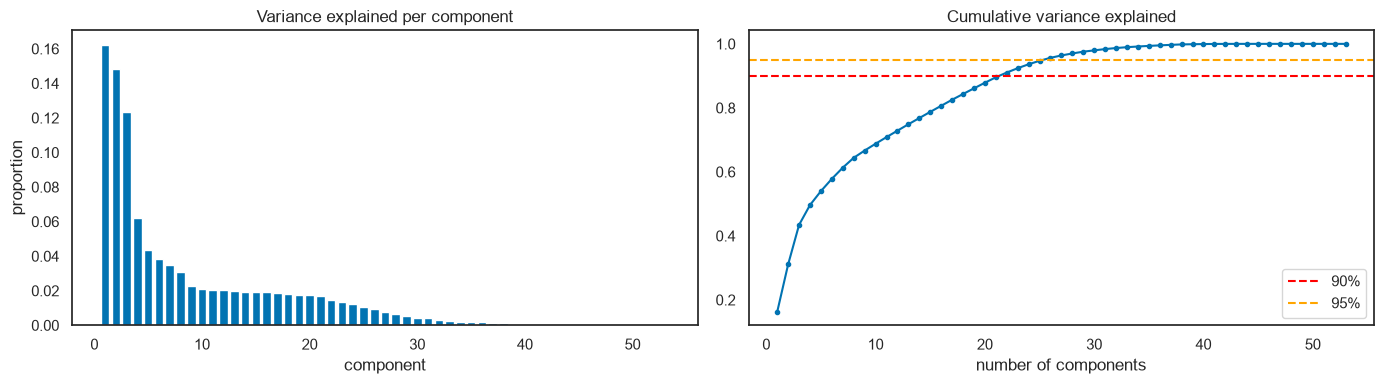

22 components explain 90% of variance (of 53 features)
26 components explain 95%


In [25]:
scaled = StandardScaler().fit_transform(clean[features])
pca = PCA().fit(scaled)
cumulative = np.cumsum(pca.explained_variance_ratio_)

n_90 = int(np.argmax(cumulative >= 0.90) + 1)
n_95 = int(np.argmax(cumulative >= 0.95) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
axes[0].set_title("Variance explained per component")
axes[0].set_xlabel("component")
axes[0].set_ylabel("proportion")

axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker="o", markersize=3)
axes[1].axhline(0.90, color="red", linestyle="--", label="90%")
axes[1].axhline(0.95, color="orange", linestyle="--", label="95%")
axes[1].set_title("Cumulative variance explained")
axes[1].set_xlabel("number of components")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"{n_90} components explain 90% of variance (of {len(features)} features)")
print(f"{n_95} components explain 95%")

In [26]:
N_COMPONENTS_SHOWN = 20

loadings = pd.DataFrame(
    pca.components_[:N_COMPONENTS_SHOWN].T,
    index=features,
    columns=[f"PC{i + 1}" for i in range(N_COMPONENTS_SHOWN)],
)

# Summary table: each component with its variance share and the features that
# most define it (its 'name'). Reads far more cleanly than a printed loop and
# stays sortable / exportable.
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
component_summary = pd.DataFrame(
    {
        "variance_explained": [
            pca.explained_variance_ratio_[i] for i in range(N_COMPONENTS_SHOWN)
        ],
        "cumulative": [cumulative_variance[i] for i in range(N_COMPONENTS_SHOWN)],
        "top_features": [
            ", ".join(loadings[f"PC{i + 1}"].abs().sort_values(ascending=False).head(4).index)
            for i in range(N_COMPONENTS_SHOWN)
        ],
    },
    index=[f"PC{i + 1}" for i in range(N_COMPONENTS_SHOWN)],
)
component_summary["variance_explained"] = (component_summary["variance_explained"] * 100).round(1).astype(str) + "%"
component_summary["cumulative"] = (component_summary["cumulative"] * 100).round(1).astype(str) + "%"

display(component_summary)

,variance_explained,cumulative,top_features
PC1,16.2%,16.2%,"bb_percent_b_20, rsi_14, stoch_d_3, stoch_k_14"
PC2,14.8%,31.1%,"sma_50, sma_20, ema_26, vwap_20"
PC3,12.3%,43.4%,"log_return_std_20, realized_vol_20_annualized,..."
PC4,6.2%,49.6%,"vix_3m, vix, fed_funds_rate, treasury_2y"
PC5,4.3%,54.0%,"vix_change_20d, macd_signal, vix_change_5d, macd"
PC6,3.8%,57.8%,"month, quarter, macd_signal, macd"
PC7,3.5%,61.3%,"macd_signal, macd, yield_curve_slope_change_20..."
PC8,3.1%,64.4%,"yield_curve_slope, treasury_2y, yield_curve_sl..."
PC9,2.3%,66.7%,"log_return_lag_1d, vix_change_5d, log_return_l..."
PC10,2.1%,68.8%,"obv, obv_change_5, macd_hist, volume_to_sma_20"


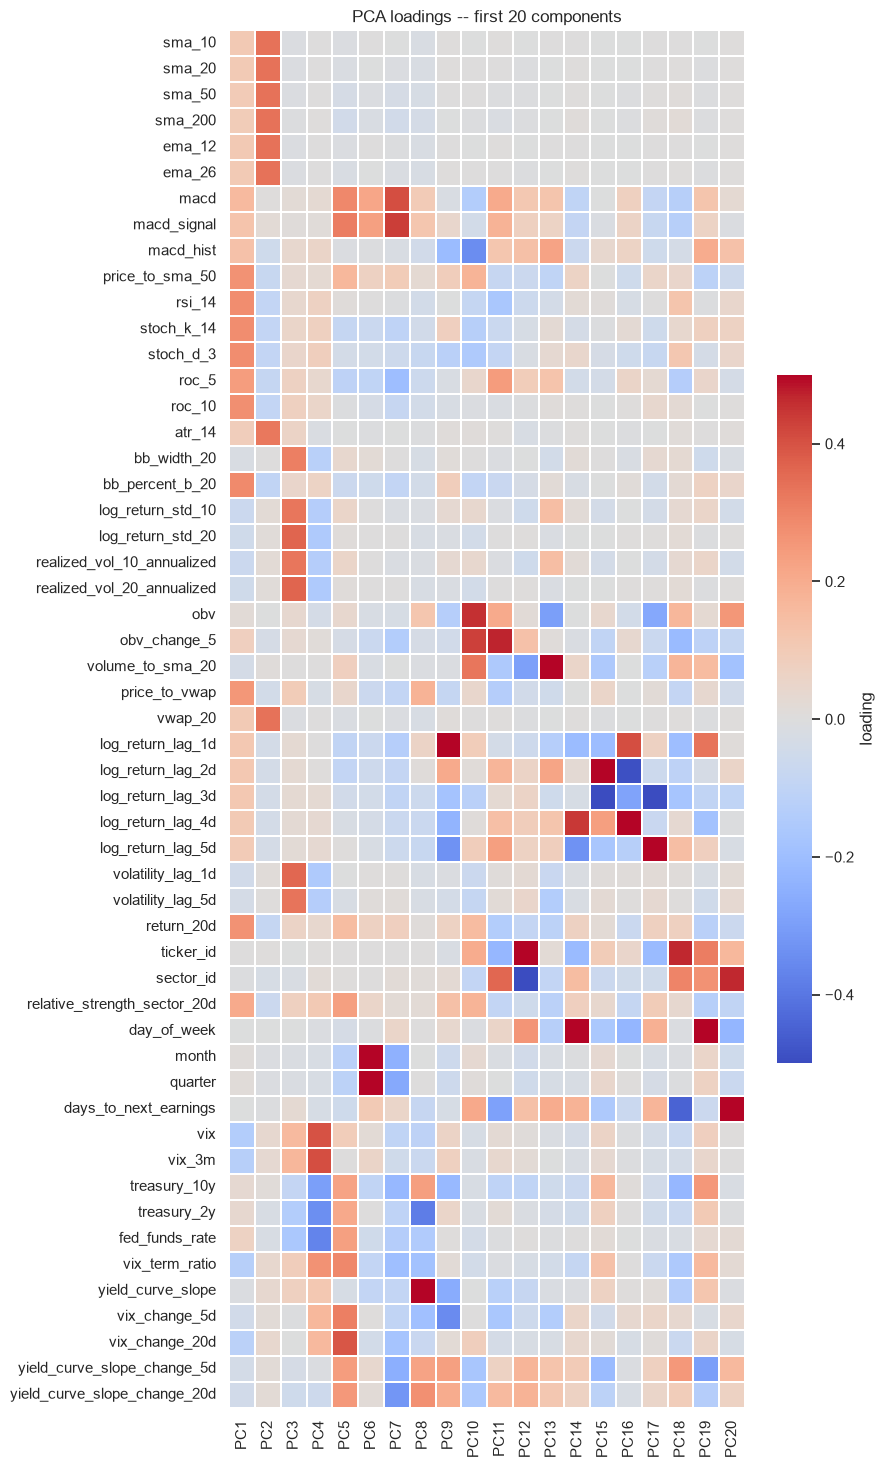

In [27]:
# Full loadings heatmap: features (rows) x components (columns). Reading down a
# column shows what composes that component; reading across a row shows which
# components a feature contributes to.
fig, ax = plt.subplots(figsize=(9, max(10, len(features) * 0.28)))
sns.heatmap(
    loadings,
    cmap="coolwarm",
    center=0,
    vmin=-0.5,
    vmax=0.5,
    linewidths=0.3,
    cbar_kws={"shrink": 0.5, "label": "loading"},
    ax=ax,
)
ax.set_title(f"PCA loadings -- first {N_COMPONENTS_SHOWN} components")
plt.tight_layout()
plt.show()

In [28]:
# VIF is computed on standardised data via statsmodels (a matrix-inverse approach
# returns NaN on the near-singular matrices that collinear features produce).
scaled_df = pd.DataFrame(StandardScaler().fit_transform(clean[features]), columns=features)

vif = pd.Series(
    {feature: variance_inflation_factor(scaled_df.values, i) for i, feature in enumerate(features)}
).sort_values(ascending=False)

vif_table = vif.to_frame("vif")
vif_table["severity"] = pd.cut(
    vif_table["vif"],
    bins=[0, 5, 10, np.inf],
    labels=["ok (<5)", "moderate (5-10)", "high (>10)"],
)

print(f"features with infinite VIF (perfect collinearity): {int(np.isinf(vif).sum())}")
print(f"features with VIF > 10: {int((vif > 10).sum())}\n")
display(vif_table.head(20).round(2))

features with infinite VIF (perfect collinearity): 2
features with VIF > 10: 33



,vif,severity
ema_12,inf,high (>10)
log_return_std_10,inf,high (>10)
treasury_2y,1.817858e+09,high (>10)
macd_signal,8.736169e+08,high (>10)
macd_hist,6.521277e+07,high (>10)
yield_curve_slope,2.760033e+07,high (>10)
treasury_10y,1.602708e+07,high (>10)
log_return_std_20,8.939888e+06,high (>10)
macd,7.817770e+06,high (>10)
realized_vol_10_annualized,3.815149e+06,high (>10)


condition number         : infinite (matrix is singular)
near-zero eigenvalues    : 5  (exact linear dependencies among features)
largest / smallest eigen : 8.6110 / -3.27e-15


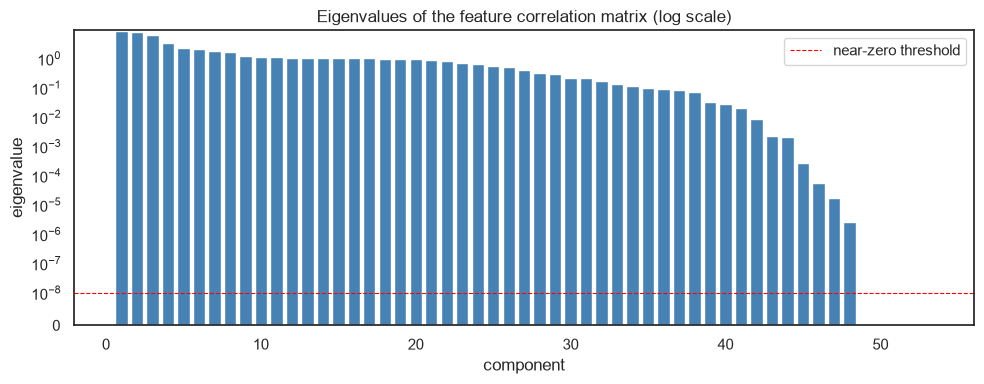

In [29]:
correlation_matrix = np.corrcoef(scaled, rowvar=False)
eigenvalues = np.linalg.eigvalsh(correlation_matrix)[::-1]

# Clip tiny negative values from floating-point error before dividing.
smallest = float(np.clip(eigenvalues[-1], 0, None))
condition_number = float(eigenvalues[0] / smallest) if smallest > 1e-12 else float("inf")
near_zero = int((eigenvalues < 1e-8).sum())

print(f"condition number         : {condition_number:,.1f}" if np.isfinite(condition_number)
      else "condition number         : infinite (matrix is singular)")
print(f"near-zero eigenvalues    : {near_zero}  (exact linear dependencies among features)")
print(f"largest / smallest eigen : {eigenvalues[0]:.4f} / {eigenvalues[-1]:.2e}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, len(eigenvalues) + 1), eigenvalues, color="steelblue")
ax.axhline(1e-8, color="red", linestyle="--", linewidth=0.8, label="near-zero threshold")
ax.set_yscale("symlog", linthresh=1e-8)
ax.set_title("Eigenvalues of the feature correlation matrix (log scale)")
ax.set_xlabel("component")
ax.set_ylabel("eigenvalue")
ax.legend()
plt.tight_layout()
plt.show()

In [30]:
TOP_PAIRS = 20

yearly = clean.copy()
yearly["year"] = yearly["date"].dt.year

strongest = redundant.head(TOP_PAIRS)

by_year = {}
for year, group in yearly.groupby("year"):
    year_corr = group[features].corr()
    by_year[year] = [
        year_corr.loc[row.feature_a, row.feature_b] for row in strongest.itertuples()
    ]

pair_labels = [f"{row.feature_a} ~ {row.feature_b}" for row in strongest.itertuples()]
pair_stability = pd.DataFrame(by_year, index=pair_labels)
pair_stability["pooled"] = strongest["corr"].values
pair_stability["range"] = (
    pair_stability[list(by_year)].max(axis=1) - pair_stability[list(by_year)].min(axis=1)
)

print("Near-zero 'range' = structurally redundant (safe to prune permanently).")
print("Large 'range'     = only redundant in some regimes; prune with care.\n")
display(pair_stability.round(3))

Near-zero 'range' = structurally redundant (safe to prune permanently).
Large 'range'     = only redundant in some regimes; prune with care.



,2022,2023,2024,2025,2026,pooled,range
log_return_std_20 ~ realized_vol_20_annualized,1.000,1.000,1.000,1.000,1.000,1.000,0.000
log_return_std_10 ~ realized_vol_10_annualized,1.000,1.000,1.000,1.000,1.000,1.000,0.000
sma_10 ~ ema_12,1.000,1.000,1.000,1.000,1.000,1.000,0.000
sma_20 ~ ema_26,1.000,1.000,1.000,1.000,1.000,1.000,0.000
sma_20 ~ ema_12,1.000,1.000,1.000,1.000,1.000,1.000,0.000
sma_20 ~ vwap_20,0.999,1.000,1.000,1.000,1.000,1.000,0.001
ema_12 ~ ema_26,1.000,1.000,1.000,1.000,1.000,1.000,0.000
ema_26 ~ vwap_20,0.999,1.000,1.000,1.000,1.000,1.000,0.001
sma_10 ~ sma_20,1.000,1.000,1.000,1.000,0.999,1.000,0.000
sma_10 ~ ema_26,1.000,1.000,1.000,1.000,0.999,1.000,0.000


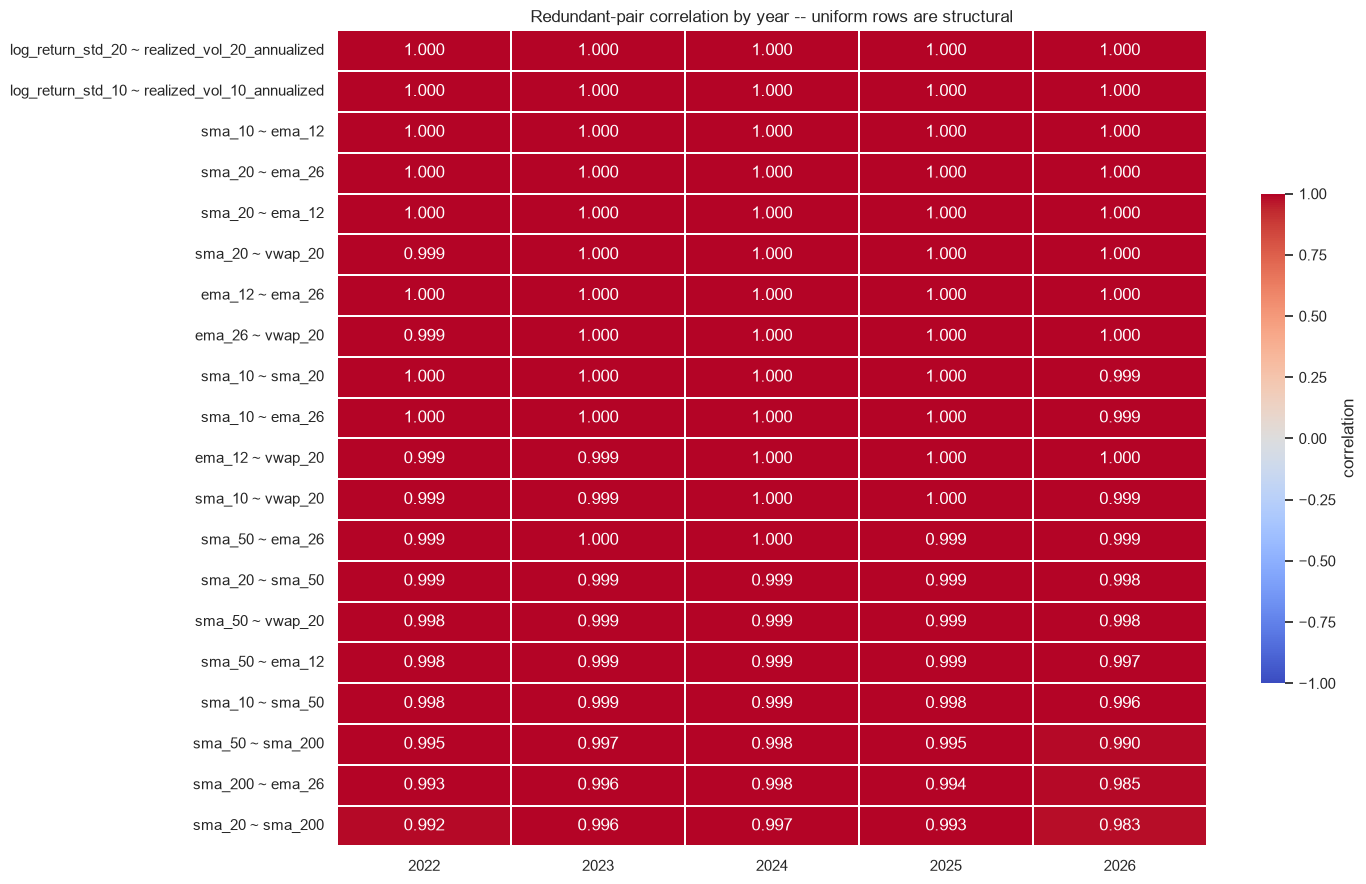

In [31]:
# Heatmap of the same: rows holding one colour across years are structural.
yearly_pairs = pair_stability.drop(columns=["pooled", "range"])

fig, ax = plt.subplots(figsize=(1.7 * yearly_pairs.shape[1] + 6, max(4, len(yearly_pairs) * 0.45)))
sns.heatmap(yearly_pairs.astype(float), annot=True, fmt=".3f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.3,
            cbar_kws={"shrink": 0.6, "label": "correlation"}, ax=ax)
ax.set_title("Redundant-pair correlation by year -- uniform rows are structural")
plt.tight_layout()
plt.show()

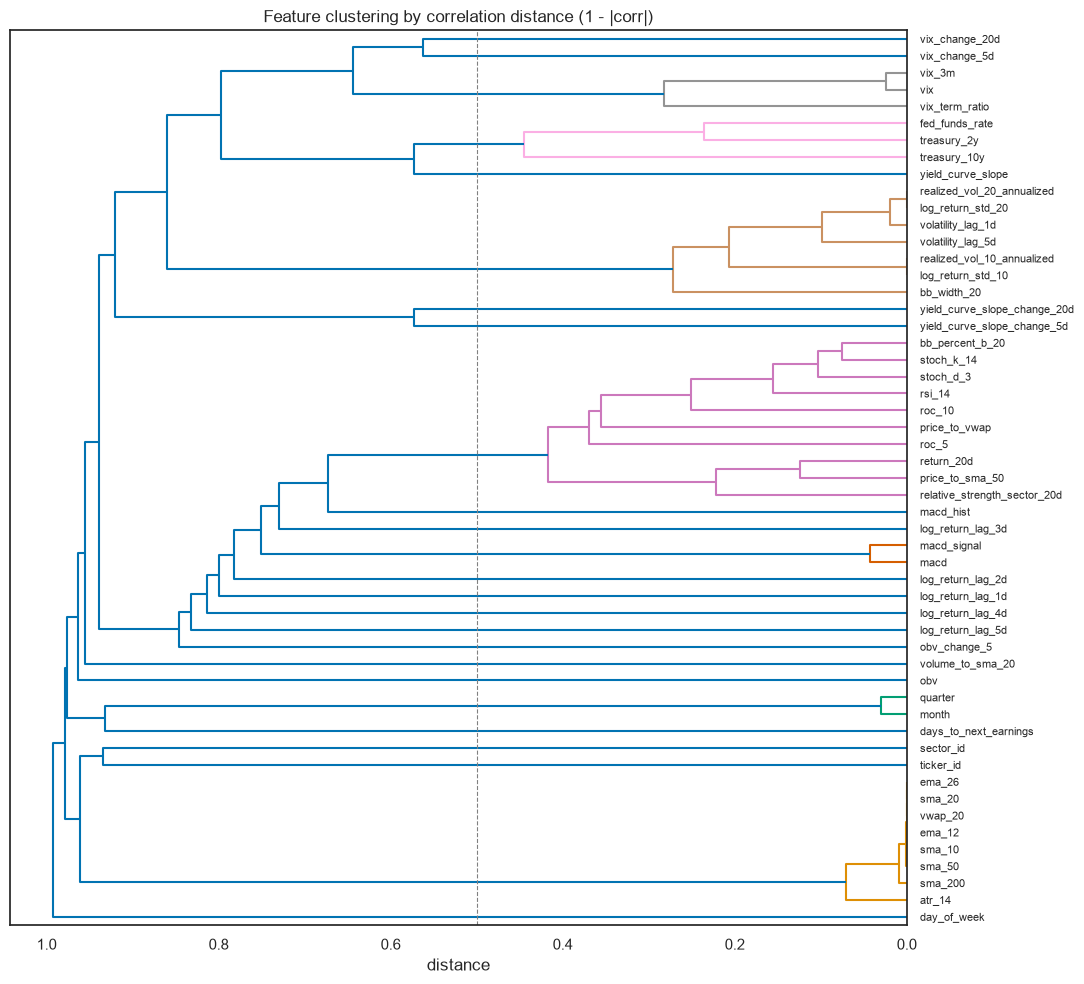

In [32]:
# Correlation distance: identical features -> 0, uncorrelated -> 1. The matrix is
# forced exactly symmetric with a zero diagonal and clipped non-negative before
# condensing, or scipy rejects it as an invalid distance matrix.
distance = (1 - corr.abs()).values.copy()
np.fill_diagonal(distance, 0.0)
distance = np.clip((distance + distance.T) / 2, 0, None)

linkage_matrix = linkage(squareform(distance, checks=False), method="average")

fig, ax = plt.subplots(figsize=(11, 10))
dendrogram(
    linkage_matrix,
    labels=features,
    orientation="left",
    color_threshold=0.5,
    leaf_font_size=8,
    ax=ax,
)
ax.axvline(0.5, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Feature clustering by correlation distance (1 - |corr|)")
ax.set_xlabel("distance")
plt.tight_layout()
plt.show()

In [33]:
# List the redundant groups at the 0.5 cut, so each branch is a 'pick one' set.
cluster_ids = fcluster(linkage_matrix, t=0.5, criterion="distance")
groups = {}
for feature, cluster_id in zip(features, cluster_ids):
    groups.setdefault(cluster_id, []).append(feature)

print("Redundant groups (features that cluster together -- keep one per group):\n")
for cluster_id, members in sorted(groups.items()):
    if len(members) > 1:
        print(f"  {members}")

Redundant groups (features that cluster together -- keep one per group):

  ['sma_10', 'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'atr_14', 'vwap_20']
  ['month', 'quarter']
  ['macd', 'macd_signal']
  ['price_to_sma_50', 'rsi_14', 'stoch_k_14', 'stoch_d_3', 'roc_5', 'roc_10', 'bb_percent_b_20', 'price_to_vwap', 'return_20d', 'relative_strength_sector_20d']
  ['bb_width_20', 'log_return_std_10', 'log_return_std_20', 'realized_vol_10_annualized', 'realized_vol_20_annualized', 'volatility_lag_1d', 'volatility_lag_5d']
  ['treasury_10y', 'treasury_2y', 'fed_funds_rate']
  ['vix', 'vix_3m', 'vix_term_ratio']


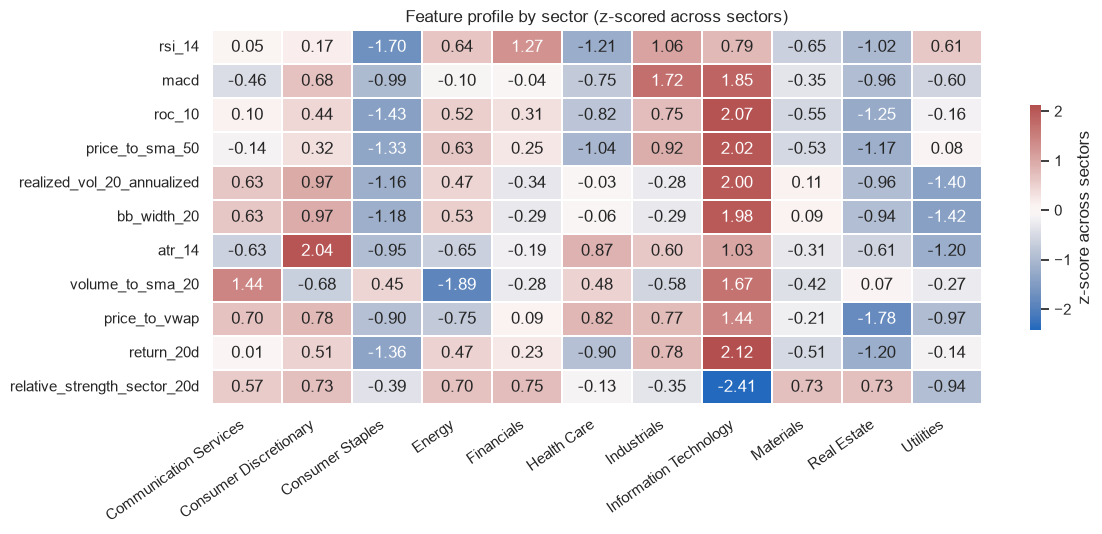

In [34]:
profile_features = [
    f for f in [
        "rsi_14", "macd", "roc_10", "price_to_sma_50",
        "realized_vol_20_annualized", "bb_width_20", "atr_14",
        "volume_to_sma_20", "price_to_vwap", "return_20d",
        "relative_strength_sector_20d",
    ] if f in clean.columns
]

sector_means = clean.groupby("gics_sector")[profile_features].mean()
sector_z = (sector_means - sector_means.mean()) / sector_means.std()

fig, ax = plt.subplots(figsize=(12, max(5, len(profile_features) * 0.5)))
sns.heatmap(
    sector_z.T,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    cbar_kws={"shrink": 0.6, "label": "z-score across sectors"},
    ax=ax,
)
ax.set_title("Feature profile by sector (z-scored across sectors)")
ax.set_xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [35]:
if not macro_present:
    print("No macro features in the matrix -- skipping macro redundancy verdict.")
else:
    non_macro = [f for f in features if f not in macro_present]
    rows = []
    for macro_feature in macro_present:
        if macro_feature not in features:
            continue  # dropped as zero-variance upstream
        cross = corr.loc[macro_feature, non_macro].abs()
        best = cross.idxmax()
        rows.append({
            "macro_feature": macro_feature,
            "closest_non_macro": best,
            "abs_corr": cross.loc[best],
        })
    macro_redundancy = pd.DataFrame(rows).set_index("macro_feature").sort_values("abs_corr", ascending=False)
    display(macro_redundancy.round(3))

    redundant = macro_redundancy[macro_redundancy["abs_corr"] > 0.85]
    novel = macro_redundancy[macro_redundancy["abs_corr"] <= 0.6]
    print(f"\nRedundant (>0.85 with an existing feature): "
          f"{list(redundant.index) if not redundant.empty else 'none'}")
    print(f"Carries novel information (<=0.6 with everything): "
          f"{list(novel.index) if not novel.empty else 'none'}")
    print("\nVerdict: feed 08b only the macro features that are NOT redundant.")
    print("If all are redundant, the rolling-vol features already capture the regime")
    print("and macro data can be dropped from the model.")

,closest_non_macro,abs_corr
macro_feature,,
vix_change_20d,roc_10,0.285
vix,price_to_sma_50,0.266
vix_3m,realized_vol_10_annualized,0.260
vix_term_ratio,price_to_sma_50,0.244
yield_curve_slope,price_to_vwap,0.239
fed_funds_rate,realized_vol_20_annualized,0.223
treasury_10y,price_to_vwap,0.212
vix_change_5d,log_return_lag_1d,0.189
treasury_2y,log_return_std_20,0.169



Redundant (>0.85 with an existing feature): none
Carries novel information (<=0.6 with everything): ['vix_change_20d', 'vix', 'vix_3m', 'vix_term_ratio', 'yield_curve_slope', 'fed_funds_rate', 'treasury_10y', 'vix_change_5d', 'treasury_2y', 'yield_curve_slope_change_20d', 'yield_curve_slope_change_5d']

Verdict: feed 08b only the macro features that are NOT redundant.
If all are redundant, the rolling-vol features already capture the regime
and macro data can be dropped from the model.


## Observations

- **Redundant pairs / groups worth pruning:**
- **Effective dimensionality** (components for 90% variance): _____ of _____ features
- **Perfect-collinearity features** (infinite VIF — e.g. the MACD/EMA identity):
- **Feature families from the dendrogram:**
- **Features that vary most by sector** (justify `sector_id`):

Note: redundancy is not a bug for the tree model, which handles correlated features fine. This mainly informs (a) pruning for a leaner feature set, (b) why the linear baseline's coefficients may be unstable, and (c) how much independent signal the set actually carries.